# **Day 73: Diffusion Models**
*Module 11 - Advanced Deep Learning*

**Diffusion models** power today's best image generators (DALL-E 2/3, Stable Diffusion, Imagen), and are used in science for weather forecasting ensembles (GenCast), super-resolution and cloud removal of satellite imagery. The idea is surprisingly simple: **gradually add noise** to data until it is pure Gaussian noise, and train a network to **reverse** the process one small step at a time.

> Diffusion models learn to remove noise step by step. Starting from pure noise and repeatedly denoising, they generate high-quality images. They power today's image generators.
>
> *Example:* A diffusion model can fill a cloud gap in an optical image by "denoising" the missing region into a plausible surface.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F, math, time
from sklearn.datasets import load_digits, make_moons
torch.manual_seed(73); rng = np.random.default_rng(73)

## **1. The Forward Process**
With a variance schedule $\beta_1, \dots, \beta_T$ (small, increasing), each step adds a little noise:
$$q(\mathbf x_t\mid\mathbf x_{t-1}) = \mathcal N\big(\sqrt{1-\beta_t}\,\mathbf x_{t-1},\;\beta_t I\big)$$
Defining $\alpha_t = 1-\beta_t$ and $\bar\alpha_t = \prod_{s\le t}\alpha_s$, we can jump to any step directly:
$$\mathbf x_t = \sqrt{\bar\alpha_t}\,\mathbf x_0 + \sqrt{1-\bar\alpha_t}\,\boldsymbol\epsilon,\qquad\boldsymbol\epsilon\sim\mathcal N(0, I)$$

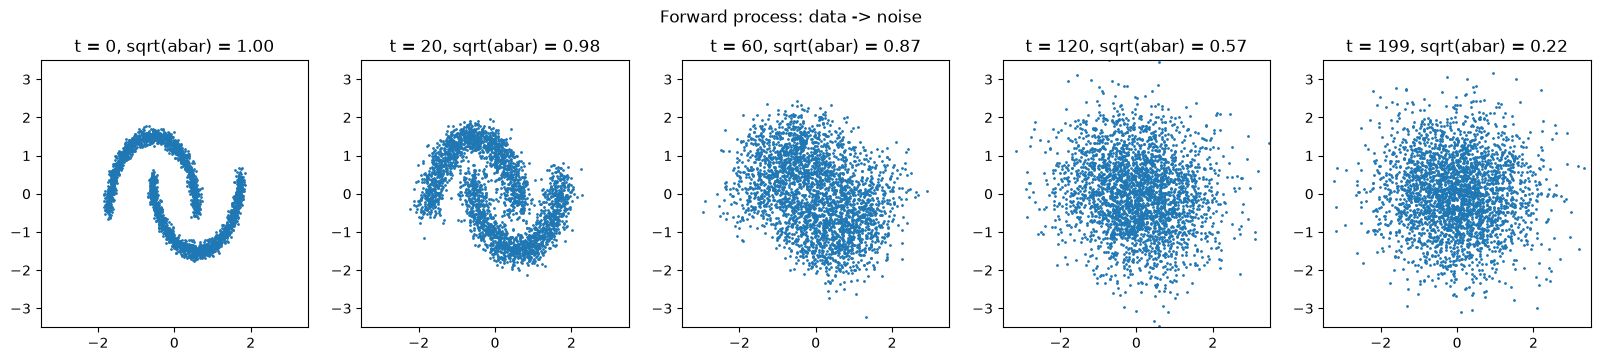

In [2]:
T = 200
betas = torch.linspace(1e-4, 0.03, T); alphas = 1 - betas; abar = torch.cumprod(alphas, 0)

def q_sample(x0, t, eps):
    return abar[t].sqrt().view(-1, *[1] * (x0.dim() - 1)) * x0 + (1 - abar[t]).sqrt().view(-1, *[1] * (x0.dim() - 1)) * eps

X2 = torch.tensor(make_moons(3000, noise=0.05, random_state=0)[0] * 1.5, dtype=torch.float32)
X2 = (X2 - X2.mean(0)) / X2.std(0)
fig, axes = plt.subplots(1, 5, figsize=(20, 3.8))
for ax, t in zip(axes, [0, 20, 60, 120, 199]):
    xt = q_sample(X2, torch.full((len(X2),), t), torch.randn_like(X2))
    ax.scatter(*xt.T, s=1); ax.set(xlim=(-3.5, 3.5), ylim=(-3.5, 3.5), title=f"t = {t}, sqrt(abar) = {abar[t].sqrt():.2f}"); ax.set_aspect("equal")
plt.suptitle("Forward process: data -> noise"); plt.show()

## **2. Training: Predict the Noise**
Sample a data point $\mathbf x_0$, a random step $t$ and noise $\boldsymbol\epsilon$; build $\mathbf x_t$; train a network $\boldsymbol\epsilon_\theta(\mathbf x_t, t)$ to predict $\boldsymbol\epsilon$:
$$\mathcal L = \mathbb E_{\mathbf x_0, t, \boldsymbol\epsilon}\big\lVert\boldsymbol\epsilon - \boldsymbol\epsilon_\theta(\mathbf x_t, t)\big\rVert^2$$
This simple regression loss is a reweighted variational bound on the likelihood (Ho et al., 2020).

## **3. Sampling: Reverse the Process**
Start from $\mathbf x_T\sim\mathcal N(0, I)$ and for $t = T,\dots,1$:
$$\mathbf x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\Big(\mathbf x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\boldsymbol\epsilon_\theta(\mathbf x_t, t)\Big) + \sigma_t\mathbf z,\qquad \sigma_t^2 = \beta_t$$

trained in 8s


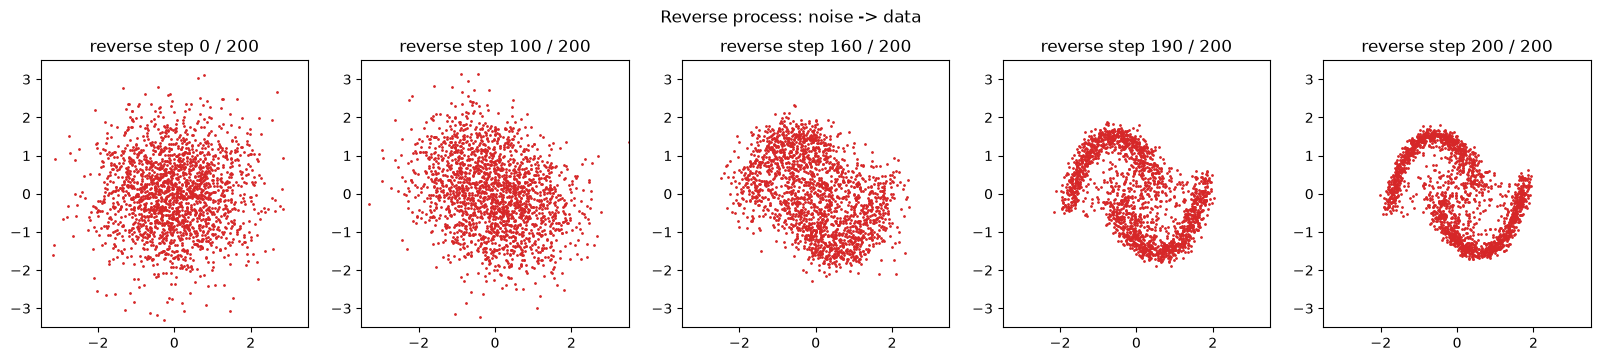

In [3]:
def time_embedding(t, dim=32):
    half = dim // 2; freqs = torch.exp(-math.log(10000) * torch.arange(half) / half)
    ang = t.float()[:, None] * freqs[None]; return torch.cat([ang.sin(), ang.cos()], 1)

class Denoiser2D(nn.Module):
    def __init__(self, h=128):
        super().__init__(); self.net = nn.Sequential(nn.Linear(2 + 32, h), nn.SiLU(), nn.Linear(h, h), nn.SiLU(), nn.Linear(h, h), nn.SiLU(), nn.Linear(h, 2))
    def forward(self, x, t): return self.net(torch.cat([x, time_embedding(t)], 1))

def train_ddpm(model, data, steps=4000, bs=256, lr=2e-3):
    opt = torch.optim.Adam(model.parameters(), lr); sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, steps); losses = []
    for s in range(steps):
        x0 = data[torch.randint(0, len(data), (bs,))]; t = torch.randint(0, T, (bs,)); eps = torch.randn_like(x0)
        loss = F.mse_loss(model(q_sample(x0, t, eps), t), eps)
        opt.zero_grad(); loss.backward(); opt.step(); sched.step(); losses.append(loss.item())
    return losses

@torch.no_grad()
def sample(model, shape, return_traj=False, **kw):
    x = torch.randn(shape); traj = [x]
    for t in reversed(range(T)):
        tt = torch.full((shape[0],), t)
        eps = model(x, tt, **kw)
        x = (x - betas[t] / (1 - abar[t]).sqrt() * eps) / alphas[t].sqrt()
        if t > 0: x = x + betas[t].sqrt() * torch.randn_like(x)
        traj.append(x)
    return (x, traj) if return_traj else x

t0 = time.perf_counter(); den2 = Denoiser2D(); losses = train_ddpm(den2, X2)
samples2, traj = sample(den2, (2000, 2), return_traj=True)
print(f"trained in {time.perf_counter() - t0:.0f}s")
fig, axes = plt.subplots(1, 5, figsize=(20, 3.8))
for ax, k in zip(axes, [0, 100, 160, 190, 200]):
    ax.scatter(*traj[k].T, s=1, c="C3"); ax.set(xlim=(-3.5, 3.5), ylim=(-3.5, 3.5), title=f"reverse step {k} / {T}"); ax.set_aspect("equal")
plt.suptitle("Reverse process: noise -> data"); plt.show()

## **4. A Diffusion Model for 8x8 Digit Images**
Same algorithm; the denoiser is now a small convolutional network with time conditioning (a mini U-Net).

trained in 215s


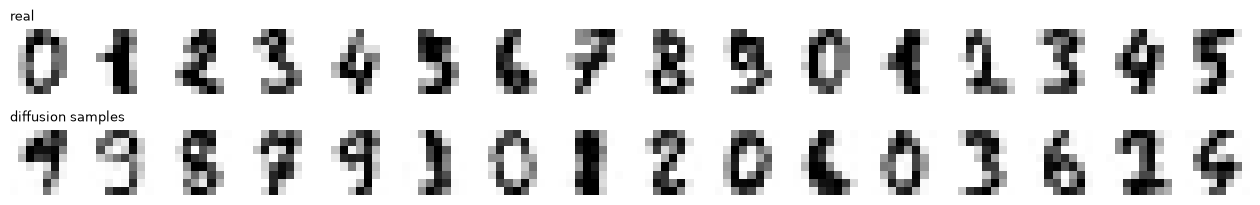

In [4]:
Xd, yd = load_digits(return_X_y=True)
imgs = torch.tensor(Xd / 8.0 - 1.0, dtype=torch.float32).view(-1, 1, 8, 8); labels = torch.tensor(yd)

class TinyUNet(nn.Module):
    def __init__(self, ch=64, n_classes=None):
        super().__init__()
        self.t_mlp = nn.Sequential(nn.Linear(32, ch), nn.SiLU(), nn.Linear(ch, ch))
        self.c_emb = nn.Embedding(n_classes + 1, ch) if n_classes else None            # last index = "no class" (for guidance)
        self.inc = nn.Sequential(nn.Conv2d(1, ch, 3, padding=1), nn.GroupNorm(8, ch), nn.SiLU())
        self.down = nn.Sequential(nn.Conv2d(ch, ch * 2, 4, 2, 1), nn.GroupNorm(8, ch * 2), nn.SiLU())         # 8 -> 4
        self.mid = nn.Sequential(nn.Conv2d(ch * 2, ch * 2, 3, padding=1), nn.GroupNorm(8, ch * 2), nn.SiLU())
        self.up = nn.Sequential(nn.ConvTranspose2d(ch * 2, ch, 4, 2, 1), nn.GroupNorm(8, ch), nn.SiLU())      # 4 -> 8
        self.out = nn.Sequential(nn.Conv2d(ch * 2, ch, 3, padding=1), nn.SiLU(), nn.Conv2d(ch, 1, 3, padding=1))
    def forward(self, x, t, c=None):
        emb = self.t_mlp(time_embedding(t))
        if self.c_emb is not None: emb = emb + self.c_emb(c)
        h1 = self.inc(x) + emb[:, :, None, None]
        h = self.up(self.mid(self.down(h1)))
        return self.out(torch.cat([h, h1], 1))                                          # skip connection

t0 = time.perf_counter(); unet = TinyUNet(); opt = torch.optim.Adam(unet.parameters(), 2e-3); sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, 6000)
for s in range(6000):
    x0 = imgs[torch.randint(0, len(imgs), (128,))]; t = torch.randint(0, T, (128,)); eps = torch.randn_like(x0)
    loss = F.mse_loss(unet(q_sample(x0, t, eps), t), eps); opt.zero_grad(); loss.backward(); opt.step(); sched.step()
gen = sample(unet, (16, 1, 8, 8)).clamp(-1, 1)
print(f"trained in {time.perf_counter() - t0:.0f}s")
fig, axes = plt.subplots(2, 16, figsize=(16, 2.4))
for j in range(16):
    axes[0, j].imshow(Xd[j].reshape(8, 8), cmap="gray_r"); axes[1, j].imshow(gen[j, 0], cmap="gray_r"); axes[0, j].axis("off"); axes[1, j].axis("off")
axes[0, 0].set_title("real", loc="left", fontsize=9); axes[1, 0].set_title("diffusion samples", loc="left", fontsize=9); plt.show()

## **5. Conditional Generation and Classifier-Free Guidance**
Condition the denoiser on a class label $c$. During training, **drop** the label (replace by a "null" token) 10-20% of the time, so one network learns both conditional and unconditional denoising. At sampling time, **classifier-free guidance** (Ho & Salimans, 2022) extrapolates:
$$\tilde{\boldsymbol\epsilon} = (1 + w)\,\boldsymbol\epsilon_\theta(\mathbf x_t, t, c) - w\,\boldsymbol\epsilon_\theta(\mathbf x_t, t, \varnothing)$$
Larger $w$ = samples more typical of the class (less diverse). Text-to-image models use exactly this, with text embeddings as $c$.

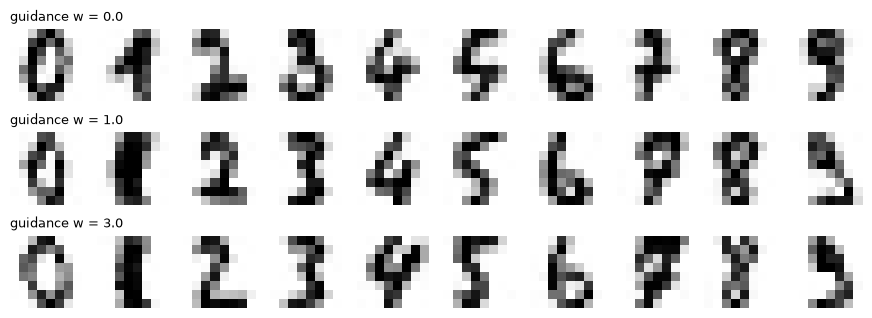

In [5]:
cunet = TinyUNet(n_classes=10); opt = torch.optim.Adam(cunet.parameters(), 2e-3); sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, 6000)
for s in range(6000):
    idx = torch.randint(0, len(imgs), (128,)); x0, c = imgs[idx], labels[idx].clone()
    c[torch.rand(128) < 0.15] = 10                                                       # null label
    t = torch.randint(0, T, (128,)); eps = torch.randn_like(x0)
    loss = F.mse_loss(cunet(q_sample(x0, t, eps), t, c), eps); opt.zero_grad(); loss.backward(); opt.step(); sched.step()

class Guided(nn.Module):
    def __init__(self, model, c, w): super().__init__(); self.m, self.c, self.w = model, c, w
    def forward(self, x, t):
        return (1 + self.w) * self.m(x, t, self.c) - self.w * self.m(x, t, torch.full_like(self.c, 10))
fig, axes = plt.subplots(3, 10, figsize=(11, 3.8))
for i, w in enumerate([0.0, 1.0, 3.0]):
    out = sample(Guided(cunet, torch.arange(10), w), (10, 1, 8, 8)).clamp(-1, 1)
    for j in range(10): axes[i, j].imshow(out[j, 0], cmap="gray_r"); axes[i, j].axis("off")
    axes[i, 0].set_title(f"guidance w = {w}", loc="left", fontsize=9)
plt.show()

# **Part 2: Going Deeper**

### The score-function view
Predicting the noise is equivalent to estimating the **score** $\nabla_{\mathbf x}\log p_t(\mathbf x) = -\boldsymbol\epsilon/\sqrt{1-\bar\alpha_t}$: the direction towards higher data density. Sampling follows the score from noise to data (Song et al., 2021 unify DDPM and score matching as stochastic differential equations).

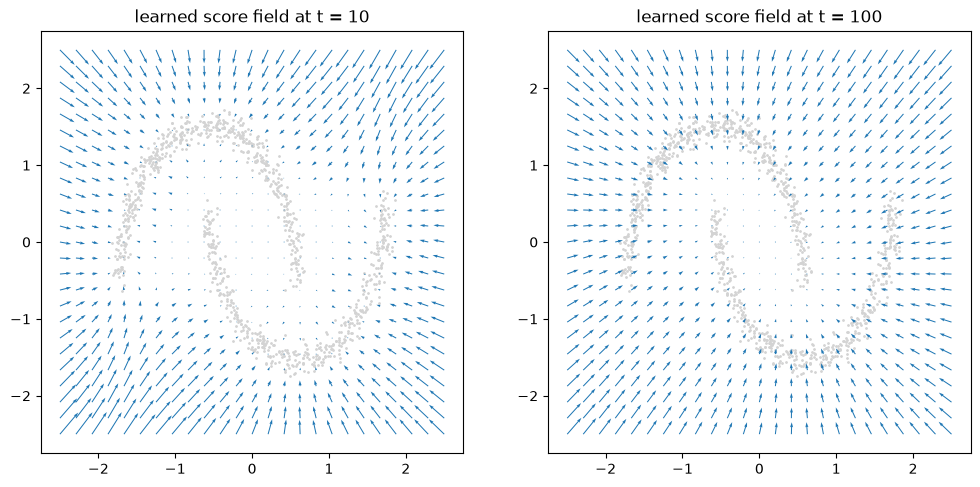

In [6]:
xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 25), np.linspace(-2.5, 2.5, 25)); grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, t in zip(axes, [10, 100]):
    with torch.no_grad(): score = -den2(grid, torch.full((len(grid),), t)) / (1 - abar[t]).sqrt()
    ax.scatter(*X2[:1000].T, s=1, c="lightgrey"); ax.quiver(grid[:, 0], grid[:, 1], score[:, 0], score[:, 1], color="C0"); ax.set_title(f"learned score field at t = {t}"); ax.set_aspect("equal")
plt.show()

### Faster sampling: DDIM
DDPM needs all T steps. **DDIM** (Song, Meng & Ermon, 2021) defines a deterministic sampler that can skip steps (e.g. 20 instead of 1000) with the **same** trained network.

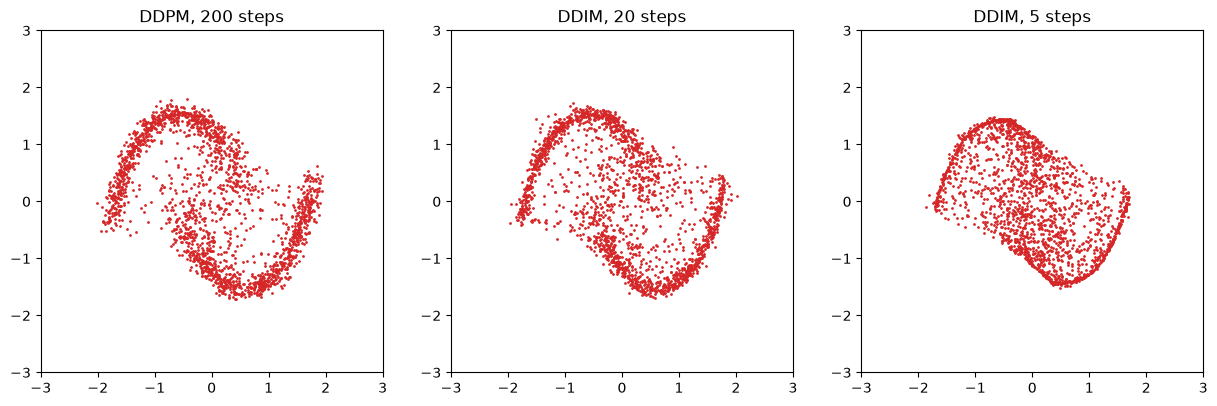

In [7]:
@torch.no_grad()
def ddim_sample(model, shape, n_steps=20):
    ts = torch.linspace(T - 1, 0, n_steps).long(); x = torch.randn(shape)
    for i, t in enumerate(ts):
        eps = model(x, torch.full((shape[0],), int(t)))
        x0_hat = (x - (1 - abar[t]).sqrt() * eps) / abar[t].sqrt()
        a_prev = abar[ts[i + 1]] if i + 1 < len(ts) else torch.tensor(1.0)
        x = a_prev.sqrt() * x0_hat + (1 - a_prev).sqrt() * eps
    return x
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, s_) in zip(axes, [("DDPM, 200 steps", samples2), ("DDIM, 20 steps", ddim_sample(den2, (2000, 2), 20)), ("DDIM, 5 steps", ddim_sample(den2, (2000, 2), 5))]):
    ax.scatter(*s_.T, s=1, c="C3"); ax.set(xlim=(-3, 3), ylim=(-3, 3), title=name); ax.set_aspect("equal")
plt.show()

### Latent diffusion and Earth-science applications
- **Latent diffusion** (Rombach et al., 2022; Stable Diffusion): run diffusion in the compressed latent space of an autoencoder (Day 71): much cheaper for large images.
- **Weather and climate**: GenCast (Price et al., 2025) generates probabilistic ensemble forecasts; diffusion downscaling of climate models.
- **Remote sensing**: cloud removal and gap-filling conditioned on SAR or other dates; super-resolution (e.g. Sentinel-2 to sub-metre); synthetic training data. As with GANs, generated detail may not be real: validate before measuring.

## **Practice Problems**
1. Use a **cosine** noise schedule ($\bar\alpha_t = \cos^2(\frac{t/T + s}{1 + s}\frac{\pi}{2})$) instead of the linear one for the 2-D model. Compare samples.
2. Train the 2-D model for only 500 steps. What do the samples look like?
3. Generate 100 samples of digit "3" with guidance w = 0 and w = 3 and compute their pixel-wise standard deviation (diversity).
4. *(Advanced)* **Inpainting** with an unconditional model: at each reverse step, replace the known pixels of $\mathbf x_{t-1}$ with a noised version of the observed pixels ($q(\mathbf x_{t-1}\mid\mathbf x_0)$). Fill the right half of a digit.

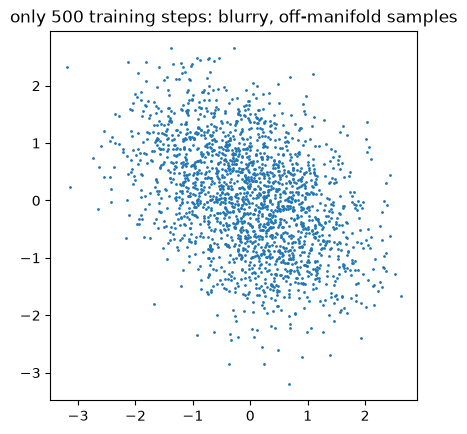

w = 0.0: mean pixel-wise std across 100 samples of '3' = 0.299


w = 3.0: mean pixel-wise std across 100 samples of '3' = 0.301


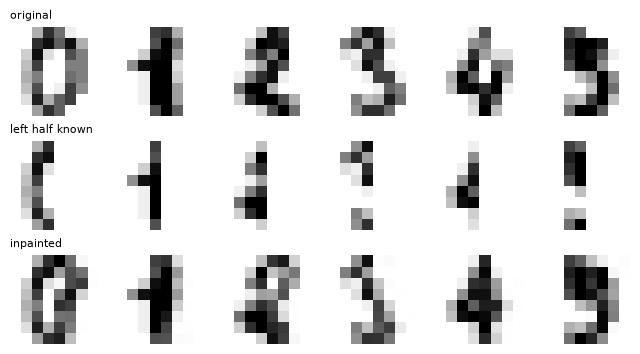

In [8]:
# Solution 1 is an open exercise: redefine betas/alphas/abar from the cosine formula, retrain Denoiser2D and compare samples.
# Solution 2
den_short = Denoiser2D(); train_ddpm(den_short, X2, steps=500)
s_short = sample(den_short, (2000, 2)); plt.scatter(*s_short.T, s=1); plt.gca().set_aspect("equal"); plt.title("only 500 training steps: blurry, off-manifold samples"); plt.show()
# Solution 3
for w in [0.0, 3.0]:
    out = sample(Guided(cunet, torch.full((100,), 3), w), (100, 1, 8, 8)).clamp(-1, 1)
    print(f"w = {w}: mean pixel-wise std across 100 samples of '3' = {out.std(0).mean():.3f}")
# Solution 4
@torch.no_grad()
def inpaint(model, x_known, mask):                     # mask = 1 where pixels are known
    x = torch.randn_like(x_known)
    for t in reversed(range(T)):
        tt = torch.full((x.shape[0],), t); eps = model(x, tt)
        x = (x - betas[t] / (1 - abar[t]).sqrt() * eps) / alphas[t].sqrt()
        if t > 0:
            x = x + betas[t].sqrt() * torch.randn_like(x)
            known_t = q_sample(x_known, torch.full((x.shape[0],), t - 1), torch.randn_like(x_known))
        else:
            known_t = x_known
        x = mask * known_t + (1 - mask) * x
    return x
target = imgs[:6]; mask = torch.zeros_like(target); mask[..., :4] = 1
filled = inpaint(unet, target, mask).clamp(-1, 1)
fig, axes = plt.subplots(3, 6, figsize=(8, 4.2))
for j in range(6):
    for i, im in enumerate([target[j, 0], target[j, 0] * mask[j, 0] + (mask[j, 0] - 1), filled[j, 0]]):
        axes[i, j].imshow(im, cmap="gray_r", vmin=-1, vmax=1); axes[i, j].axis("off")
for i, t_ in enumerate(["original", "left half known", "inpainted"]): axes[i, 0].set_title(t_, loc="left", fontsize=8)
plt.show()

## **Key References**
- Sohl-Dickstein, J., Weiss, E., Maheswaranathan, N., & Ganguli, S. (2015). Deep unsupervised learning using nonequilibrium thermodynamics. *ICML 2015*.
- Ho, J., Jain, A., & Abbeel, P. (2020). Denoising diffusion probabilistic models. *NeurIPS 33*.
- Song, Y. et al. (2021). Score-based generative modeling through stochastic differential equations. *ICLR 2021*.
- Song, J., Meng, C., & Ermon, S. (2021). Denoising diffusion implicit models. *ICLR 2021*.
- Ho, J., & Salimans, T. (2022). Classifier-free diffusion guidance. arXiv:2207.12598.
- Rombach, R., Blattmann, A., Lorenz, D., Esser, P., & Ommer, B. (2022). High-resolution image synthesis with latent diffusion models. *CVPR 2022*.
- Price, I. et al. (2025). Probabilistic weather forecasting with machine learning. *Nature*, 637, 84-90 (GenCast).